# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fontTools.subset import subset
from openpyxl.chart import trendline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
import warnings

from tblib.decorators import return_error

warnings.filterwarnings('ignore', category=UserWarning, message='.*unknown categories.*')

In [2]:
# Defining a data audit function that will help quickly evaluate key characteristics of the dataset
def data_audit(df: pd.DataFrame, n_unique_preview: int = 8) -> pd.DataFrame:
    summary = []
    for col in df.columns:
        s = df[col]

        # Calculate min/max only for numeric columns
        if pd.api.types.is_numeric_dtype(s):
            min_val = float(s.min())
            median_val = float(s.median())
            max_val = float(s.max())
        else:
            min_val = None
            median_val = None
            max_val = None

        summary.append({
            'column': col,
            'dtype': str(s.dtype),
            'n_missing': int(s.isna().sum()),
            'pct_missing': float(s.isna().mean()),
            'n_unique': int(s.nunique(dropna=True)),
            'min': min_val,
            'median': median_val,
            'max': max_val,
            "example_values": ", ".join(map(str, s.dropna().unique()[:n_unique_preview])),
        })

    out = pd.DataFrame(summary).sort_values(
        ["pct_missing", "n_unique"], ascending=[False, True]
    )
    return out

In [3]:
df = pd.read_excel('../data/hg-in-fish.xlsx')

In [4]:
print("There are", df.shape[0], "rows and", df.shape[1], "columns in the dataset.")

There are 6373 rows and 25 columns in the dataset.


In [5]:
# Calling the data audit function
data_audit(df)

,column,dtype,n_missing,pct_missing,n_unique,min,median,max,example_values
18,LengthEstimateFactor,str,6371,0.999686,1,None,None,None,Y
23,Aging Structure,str,1586,0.248862,7,None,None,None,"Otolith, Unknown, Cleithrum, Otolith , Fin Ray..."
22,Age (years),object,1586,0.248862,33,None,None,None,"Unknown, 9, 6, 4, 8, 5, 10, 7"
17,Total LengthMeasurement,str,1199,0.188137,4,None,None,None,"Field, Unknown, Lab, Field"
15,Fork LengthMeasurement,str,1082,0.169779,3,None,None,None,"Field, Unknown, Field"
20,WeightMeasurement,str,137,0.021497,4,None,None,None,"Field, Unknown, Lab, Field"
1,Sample_ID,object,2,0.000314,6337,None,None,None,"21-FM-LKWH-01, 21-FM-LKWH-02, 21-FM-LKWH-03, 2..."
3,Date_flag,object,1,0.000157,3,None,None,None,"0, Unknown, 1"
21,Maturity,str,0,0.000000,4,None,None,None,"Mature, Immature, Unknown, Triploid"
13,Sex,str,0,0.000000,5,None,None,None,"Female, Male, Unknown, Female , Male"


There are several things we can do to make these data more useful.
- Columns should be renamed to be easier to work with
- There are numeric data columns that are assigned a `str` or `object` dtype that should be changed
- There are string values that likely have surrounding whitespace (e.g. `sex`) that should be stripped
- The `weight` column is in grams but the mercury measurements are mg per kg which should be changed

In [6]:
# Creating a dictionary to rename the relevant columns
col_renames = {'Collection Date': 'coll_date', 'Waterbody Name': 'w_name', 'Waterbody Type': 'w_type',
               'Common Name': 'common_name', 'Sex': 'sex', 'Fork Length (mm)': 'f_length', 'Total Length (mm)': 't_length',
               'Weight (g)': 'weight', 'Maturity': 'maturity', 'Age (years)': 'age', 'Hg (mg/kg)': 'hg'}

# Renaming the columns using the dictionary
df.rename(columns=col_renames, inplace=True)

In [7]:
# Defining the columns to keep for further analysis
cols = ['coll_date', 'w_name', 'w_type', 'common_name', 'sex', 'f_length', 't_length', 'weight', 'maturity', 'age', 'hg']

# Creating a new dataframe that only has the desired columns
df = df[cols]

In [8]:
# Assigning the columns needed to be converted into numeric values to a variable
columns_to_convert = ['f_length', 't_length', 'weight', 'age', 'hg']

# Converting the columns to numeric dtype
df[columns_to_convert] = df[columns_to_convert].apply(lambda x: pd.to_numeric(x, errors='coerce')) # Coerce will replace any unknown values with NaN

In [9]:
# Converting weight from grams to kilograms
df['weight'] = df['weight'] / 1000

In [10]:
# Stripping any string values that have surrounding whitespace
for col in df.columns:
    if df[col].dtype == 'str': # Checking if the column is a string
        print("The current number of unique values in", col, "is", df[col].nunique(), ". Stripping string values...") # Printing the number of unique values for later comparison
        df[col] = df[col].str.strip() # Stripping the string values
        print(col, "values have been stripped. There are now", df[col].nunique(), "unique values.") # Confirm the results and see if any changes happened
    else:
        print(col, "is not a string. Passing...") # Any columns that are not str are skipped
    print("-----------------------------------------------------")

coll_date is not a string. Passing...
-----------------------------------------------------
The current number of unique values in w_name is 143 . Stripping string values...
w_name values have been stripped. There are now 142 unique values.
-----------------------------------------------------
The current number of unique values in w_type is 6 . Stripping string values...
w_type values have been stripped. There are now 5 unique values.
-----------------------------------------------------
The current number of unique values in common_name is 23 . Stripping string values...
common_name values have been stripped. There are now 22 unique values.
-----------------------------------------------------
The current number of unique values in sex is 5 . Stripping string values...
sex values have been stripped. There are now 3 unique values.
-----------------------------------------------------
f_length is not a string. Passing...
-----------------------------------------------------
t_length is

All surrounding whitespace was removed, which reduced the number of unique values.

In [11]:
# Converting the column to a datetime datatype
df['coll_date'] = pd.to_datetime(df['coll_date'])

In [12]:
min_year = df['coll_date'].dt.year.min() # Extracting the minimum year from the 'coll_date' column
max_year = df['coll_date'].dt.year.max() # Extracting the maximum year from the 'coll_date' column

print("The dataset spans the years of", min_year, "to", max_year)

The dataset spans the years of 1997 to 2021


In [13]:
# Adding a year column
df['year'] = df['coll_date'].dt.year

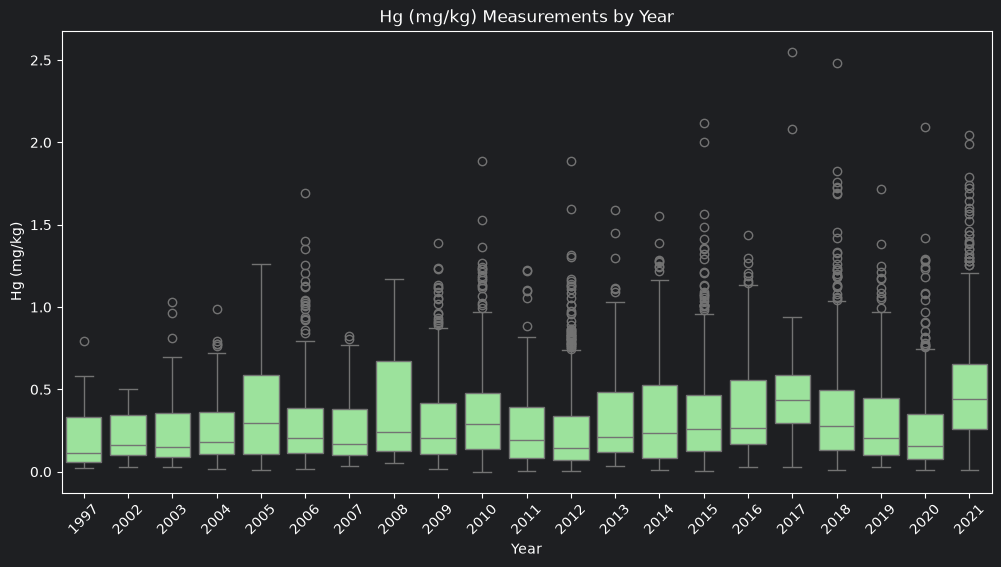

In [14]:
# Plotting a boxplot to compare the distribution of mercury by year
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='year', y='hg', color='lightgreen')
plt.title('Hg (mg/kg) Measurements by Year')
plt.xlabel('Year')
plt.ylabel('Hg (mg/kg)')
plt.xticks(rotation=45)
plt.show()

The boxplot shows roughly similar distributions over time.

In [15]:
# Creating a dataframe with a median aggregation of all samples collected per year
year_list = []
mercury_list = []

for year in df['year'].unique():
    year_list.append(year)
    mercury_list.append(df[df['year'] == year]['hg'].median())

df_hg_mercury = pd.DataFrame({
    'year': year_list,
    'hg': mercury_list
})

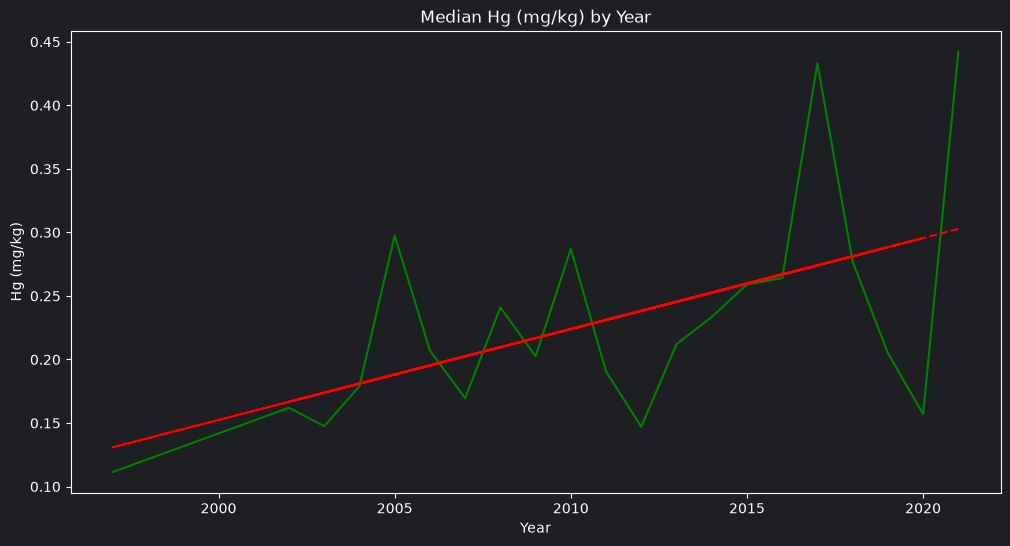

In [16]:
# Calculating the linear trend line
z = np.polyfit(df_hg_mercury['year'], df_hg_mercury['hg'], 1)
p = np.poly1d(z)

# Plotting the line plot and trendline
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hg_mercury, x='year', y='hg', color='green')
plt.plot(df_hg_mercury['year'], p(df_hg_mercury['year']), 'r--')
plt.title('Median Hg (mg/kg) by Year')
plt.xlabel('Year')
plt.ylabel('Hg (mg/kg)')
plt.show()

The trendline shows the median concentration of all samples collected per year is **increasing**.

In [17]:
# Creating a pivot table to group by common name and year
pivoted_df = df.pivot_table(
    index='common_name',
    columns='year',
    values='hg',
    aggfunc='mean',
    dropna=False,
).sort_index()

pivoted_df

year,1997,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
common_name,,,,,,,,,,,,,,,,,,,,,
Brook Trout,NaN,NaN,0.274000,NaN,NaN,NaN,NaN,NaN,0.123870,0.211100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brown Trout,NaN,NaN,0.427000,NaN,NaN,0.031200,NaN,NaN,NaN,NaN,...,0.084000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Burbot,0.383700,NaN,0.302379,0.262000,0.436500,0.094250,0.266000,NaN,NaN,NaN,...,NaN,0.242000,0.700000,NaN,NaN,NaN,0.132000,0.192000,NaN,NaN
Cisco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.086654,NaN,NaN,NaN,NaN,NaN,0.094643,NaN,NaN,NaN
Cutthroat Trout,0.043500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flathead Chub,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.174000,NaN,NaN,NaN,NaN,NaN,NaN
Goldeye,NaN,NaN,NaN,NaN,NaN,0.512500,NaN,NaN,NaN,NaN,...,NaN,NaN,0.514733,0.465643,0.365571,NaN,NaN,NaN,NaN,NaN
Lake Chub (Cisco),0.183000,NaN,0.135400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lake Trout,NaN,NaN,NaN,NaN,NaN,NaN,0.446688,NaN,NaN,0.271167,...,NaN,NaN,NaN,NaN,0.122500,NaN,NaN,0.145650,NaN,NaN


In [18]:
df.to_csv('../data/processed_data/processed_data.csv', index=False)